In [1]:
# Imports
import rasterio
import rasterio.plot
from rasterio.windows import Window
import geopandas as gpd
from rasterio.mask import mask
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import pearsonr

import plotly.graph_objects as go

Exploring different ways of plotting the results

In [2]:

park_vga = gpd.read_file("../../outputs/method_03_hex/Woodhouse_Moor_10_m_grid_hex_buffer_100m_vis_hex.geojson")
park_gdf= gpd.read_file("../../processed_datasets/Leeds_Woodhouse_Moor_park_boundaries.geojson")
park_vga.head()

TARGET_CRS = 'EPSG:27700'

# Ok, again I will have to convert the CRS
park_vga_bng = park_vga.to_crs(epsg=27700)

In [3]:
print(f"Original park CRS: {park_gdf.crs}")

# Reproject park to target CRS if needed
if park_gdf.crs != TARGET_CRS:
    park_gdf = park_gdf.to_crs(TARGET_CRS)
    print(f"Reprojected park to {TARGET_CRS}")
else:
    print(f"Park already in {TARGET_CRS}")

# Extract park boundary geometry (now in EPSG:27700)
park_boundary = park_gdf.geometry.iloc[0]
print(f"Park boundary CRS: {park_gdf.crs}")

Original park CRS: EPSG:4326
Reprojected park to EPSG:27700
Park boundary CRS: EPSG:27700


## Option 1: Simple scatter plot

This is what we currently have; it'sset to be semi transparent and can be overlaid/underlaid other data layers

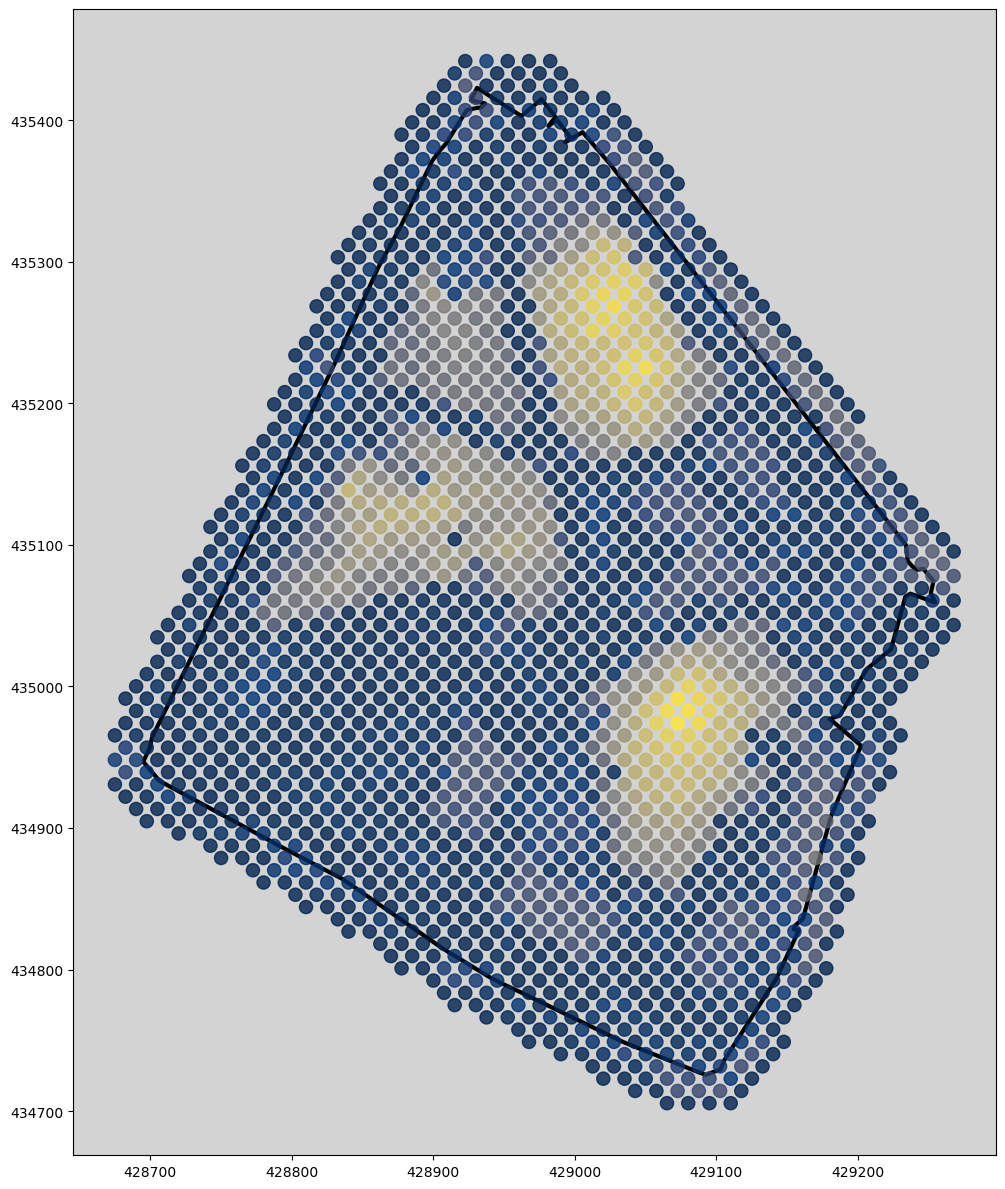

In [4]:
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor('lightgrey')
park_gdf.boundary.plot(ax=ax, color='black', linewidth=3, zorder=0)
park_vga_bng.plot(column='visibility_pct', cmap="cividis", ax=ax, markersize=90, alpha=0.8)
plt.tight_layout()
plt.show()

# Hexmap

Note: the choice of hexmap here is somewhat facetious in terms of how I've applied it, given that I'm just using the hexgrid option from matplotlib;
the key important point is that the underlying *analysis* was done on a hexagonal grid.

In [5]:
def create_hex_heatmap(points_gdf, spacing=10, column='visibility_pct', cmap='cividis', figsize=(14, 12)):
    """
    Convert point-based map to hexagonal heatmap.
    
    Parameters:
    points_gdf: GeoDataFrame with point geometries and data column
    spacing: circumradius of hexagons (should match grid spacing)
    column: column name to color by
    cmap: matplotlib colormap
    figsize: figure size
    
    Returns:
    GeoDataFrame with hexagon geometries and visualization
    """
    from shapely.geometry import Polygon
    import matplotlib.pyplot as plt
    
    hexagons = []
    
    for idx, row in points_gdf.iterrows():
        point = row.geometry
        
        # Create hexagon centered at point
        angles = np.linspace(0, 2*np.pi, 7)
        hex_x = point.x + spacing * np.cos(angles)
        hex_y = point.y + spacing * np.sin(angles)
        hexagon = Polygon(list(zip(hex_x, hex_y)))
        
        hexagons.append({
            'geometry': hexagon,
            column: row[column]
        })
    
    hex_gdf = gpd.GeoDataFrame(hexagons, crs=points_gdf.crs)
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor('white')
    
    # Plot hexagons colored by column
    hex_gdf.plot(column=column, cmap=cmap, ax=ax, edgecolor='black', linewidth=0.5, alpha=0.9)
    
    # Add park boundary
    park_boundary = gpd.GeoSeries([park_boundary], crs=points_gdf.crs)
    park_boundary.boundary.plot(ax=ax, color='darkred', linewidth=2, linestyle='--', zorder=10)
    
    ax.set_title(f'Visibility Analysis - Hexagonal Heatmap', fontsize=14)
    ax.axis('off')
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, 
                               norm=plt.Normalize(vmin=hex_gdf[column].min(), 
                                                vmax=hex_gdf[column].max()))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Visibility %')
    
    plt.tight_layout()
    plt.show()
    
    return hex_gdf

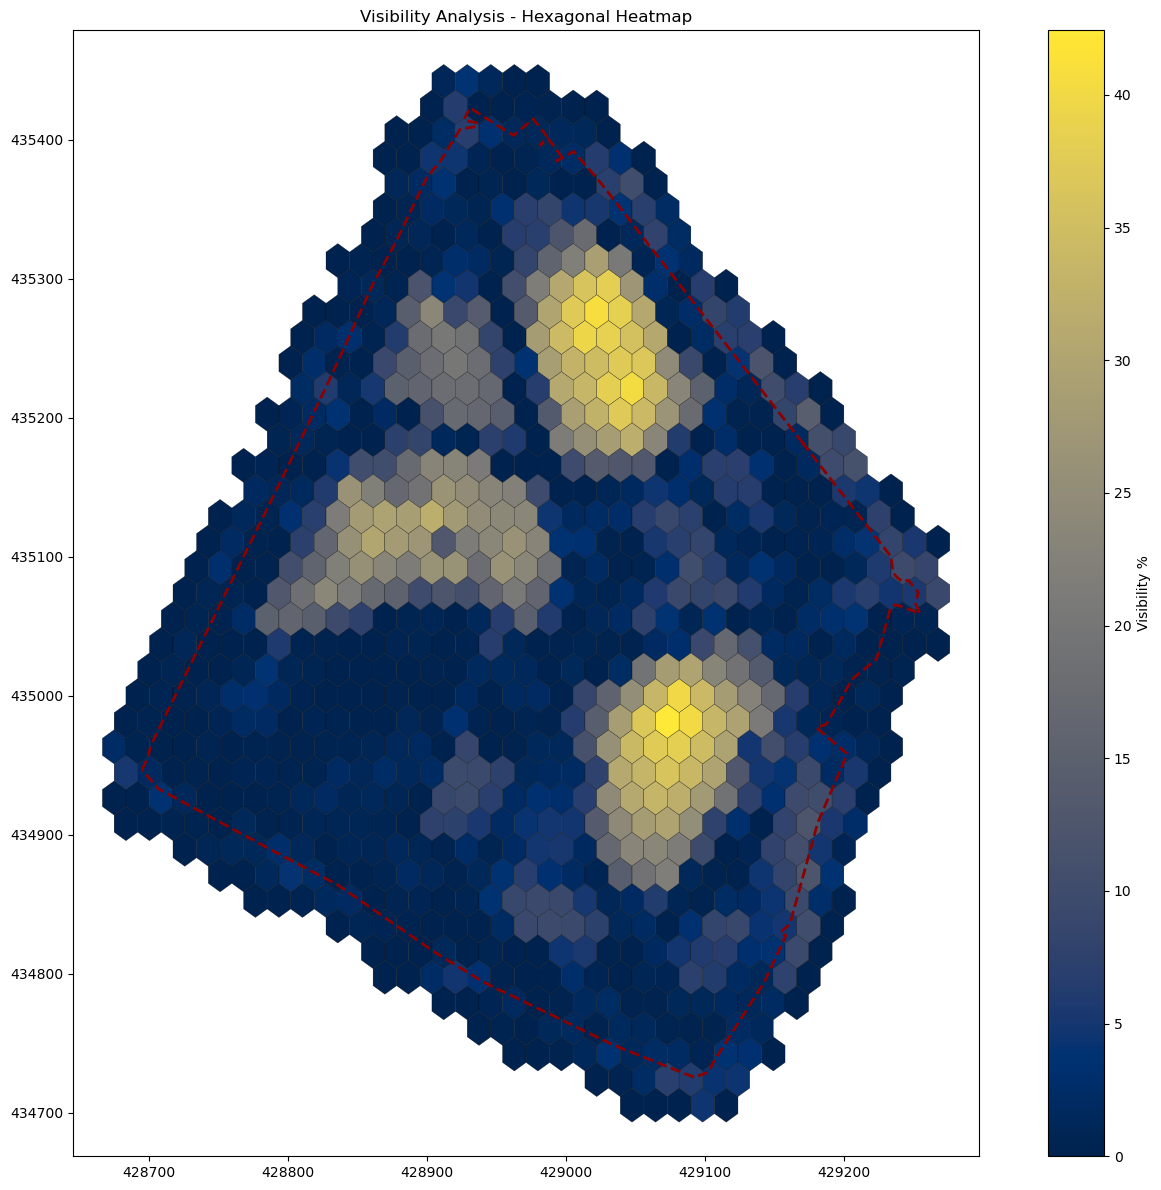

In [6]:
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor('white')

# Extract coordinates
x = park_vga_bng.geometry.x
y = park_vga_bng.geometry.y
c = park_vga_bng['visibility_pct']

# Create hexbin
hexbin = ax.hexbin(x, y, C=c, gridsize=35, cmap='cividis', edgecolors='black', linewidths=0.2, mincnt=1)
park_gdf.boundary.plot(ax=ax, color='darkred', linewidth=2, linestyle='--', zorder=10)

ax.set_title('Visibility Analysis - Hexagonal Heatmap')
cbar = plt.colorbar(hexbin, ax=ax, label='Visibility %')
plt.tight_layout()
plt.show()

## Some form of heatmap

Instead of a point/hexmap, there are possibly some other ways to show this dataset

- Still want the user to be able to hover over and see values
- Maybe contour plot style?

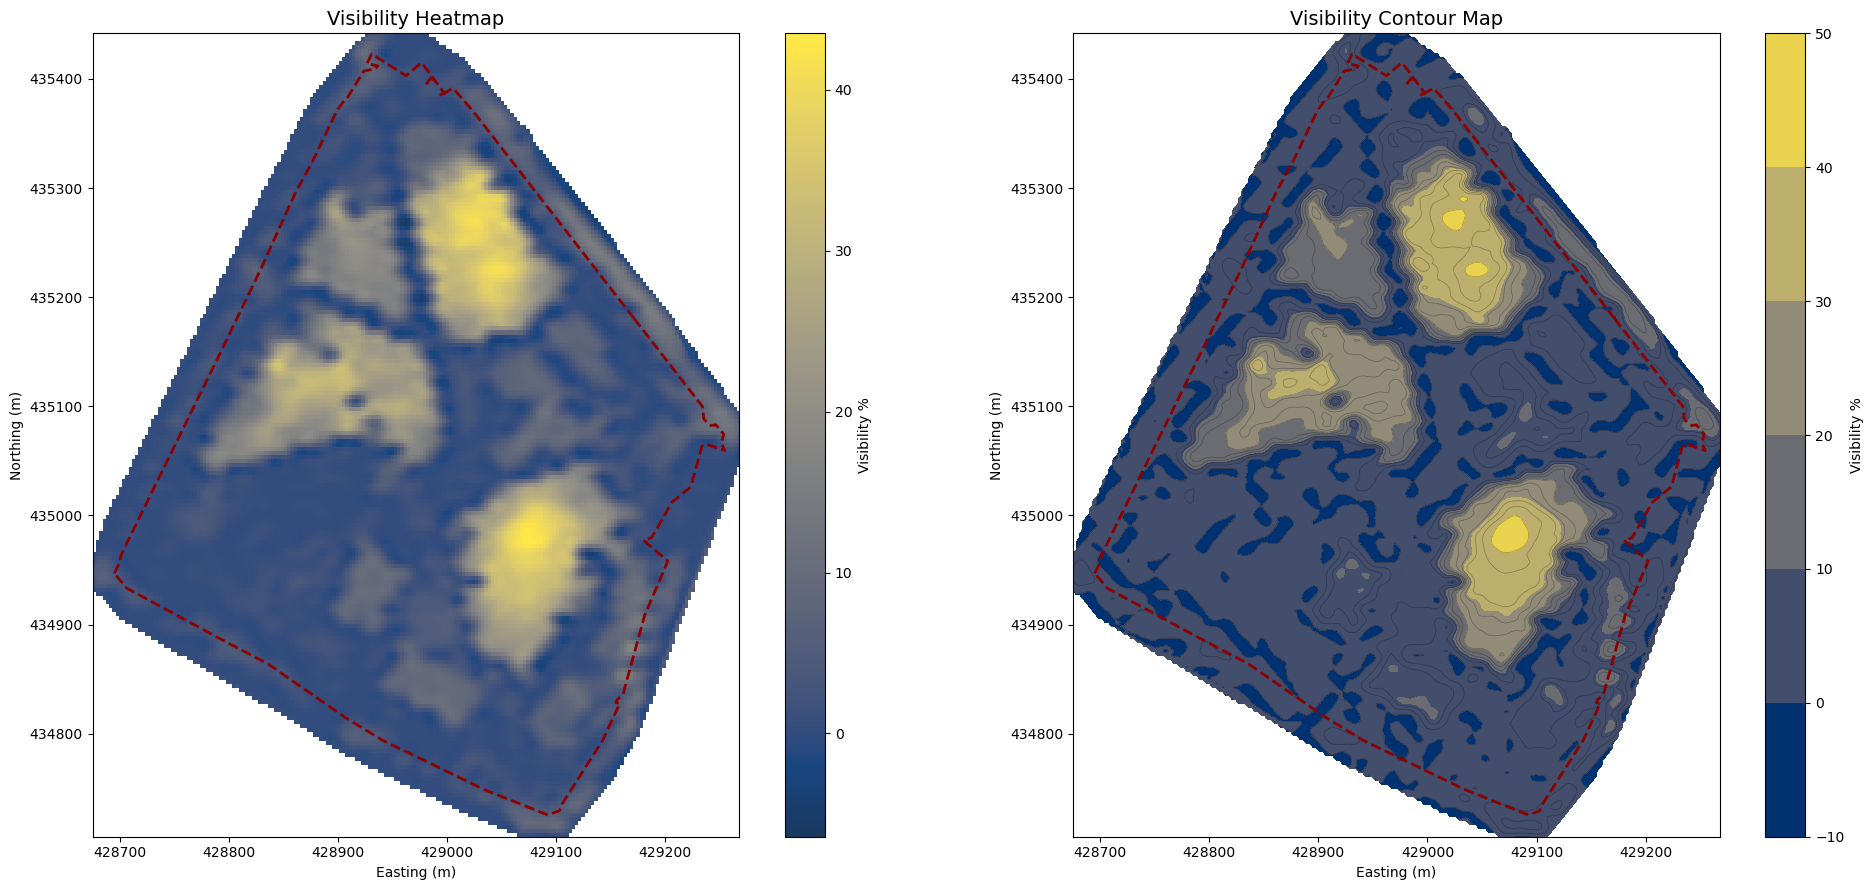

In [22]:
from scipy.interpolate import griddata

# Extract coordinates and values
x = park_vga_bng.geometry.x.values
y = park_vga_bng.geometry.y.values
z = park_vga_bng['visibility_pct'].values

# Create a regular grid for interpolation
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Interpolate scattered data onto regular grid
grid_z = griddata((x, y), z, (grid_x, grid_y), method='cubic')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# Heatmap
im1 = ax1.imshow(grid_z, extent=[x_min, x_max, y_min, y_max], origin='lower', 
                  cmap='cividis', aspect='auto', alpha=0.9)
park_gdf.boundary.plot(ax=ax1, color='darkred', linewidth=2, linestyle='--', zorder=10)
ax1.set_title('Visibility Heatmap', fontsize=14)
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
cbar1 = plt.colorbar(im1, ax=ax1, label='Visibility %')

# Contour plot
contour = ax2.contourf(grid_x, grid_y, grid_z, levels=5, cmap='cividis')
ax2.contour(grid_x, grid_y, grid_z, levels=15, colors='black', linewidths=0.5, alpha=0.3)
park_gdf.boundary.plot(ax=ax2, color='darkred', linewidth=2, linestyle='--', zorder=10)
ax2.set_title('Visibility Contour Map', fontsize=14)
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
cbar2 = plt.colorbar(contour, ax=ax2, label='Visibility %')

plt.tight_layout()
plt.show()

In [23]:
# Could potentially jsut show the hight visibility areas if that's of interest?